In [8]:
pip install mne seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ferna\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [ ]:
import openneuro as on

dataset_id = 'ds006803'
download_dir = './data_openneuro'

print(f"Iniciando la descarga del dataset: {dataset_id}...")

# Descarga el dataset completo
on.download(dataset=dataset_id, target_dir=download_dir)

print(f"Descarga completada en: {download_dir}")

## Descargar solo los archivos relacionados con una sesión específica
#on.download(dataset=dataset_id, target_dir=download_dir, include=['sub-01e'])

Iniciando la descarga del dataset: ds006803...

👋 Hello! This is openneuro-py 2023.1.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds006803 …


📁 Traversing directories for ds006803 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 7 files (5 concurrent downloads). 
✅ Finished downloading ds006803.
 
🧠 Please enjoy your brains.
 
Descarga completada en: ./data_openneuro


Re-downloading .bidsignore: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading README: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading dataset_description.json: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading CHANGES: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading extra_metadata.xlsx: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading participants.tsv: file size mismatch.: 0.00B [00:00, ?B/s]

Re-downloading participants.json: file size mismatch.: 0.00B [00:00, ?B/s]

In [2]:
# Libraries
import pandas as pd
import numpy as np
import mne
from pathlib import Path
from scipy.signal.windows import gaussian
from mne.time_frequency import tfr_array_morlet

In [3]:
main_path = 'data_openneuro'
#Subjects lit

sub_list = pd.read_csv(f'{main_path}/participants.tsv',  sep='\t')
print(sub_list.head())



  participant_id  Gender  Age Group
0        sub-01c    Male   19   con
1        sub-02c    Male   19   con
2        sub-03c  Female   19   con
3        sub-04c    Male   20   con
4        sub-05c    Male   19   con


In [25]:
#normalizacion z-score

import numpy as np
import pandas as pd
import mne
from mne.time_frequency import tfr_array_morlet
from pathlib import Path
from scipy.signal.windows import gaussian

# Configuración
CWT_DIR = Path('D:/cwt_results_complex')
CWT_DIR.mkdir(exist_ok=True)
target_channels = ['Fz', 'C3', 'C4', 'Cz', 'Pz', 'PO7', 'PO8', 'Oz']

freqs = np.linspace(4, 12, num=12)
n_cycles = freqs / 2

for index, row in sub_list.iterrows():
    sub_id = row['participant_id']
    #Carga de datos 
    raw = mne.io.read_raw_eeglab(f'{main_path}/{sub_id}/ses-2/eeg/{sub_id}_ses-2_task-STEMSKILLS_eeg.set')
    raw.pick_channels(target_channels) # Solo nos quedamos con tus 8 canales
    
    fs = raw.info['sfreq']
    df_events = pd.read_csv(f'{main_path}/{sub_id}/arithmetic_responses.csv')
    
    # Preparación de épocas
    quest_samples = (df_events['Question_appearance'] * fs - 3 * fs).astype(int)
    ans_samples = (df_events['Answer_time'] * fs - 3 * fs).astype(int)
    
    all_epochs_complex = []

    print(f'Procesando Z-score para {sub_id}...')
    for i in range(len(quest_samples)):
        t_start = quest_samples[i] / fs - 1
        t_end = ans_samples[i] / fs

        if (t_end - t_start) < (n_cycles[0] / freqs[0]):
            continue

        # Segmentación
        segment_raw = raw.copy().crop(tmin=t_start, tmax=t_end)
        segment = segment_raw.get_data().astype(np.float32)
        n_channels, n_times = segment.shape
        
        # Ventana Gaussiana
        window = gaussian(n_times, std=n_times/4)
        segment_windowed = segment * window
        
        # 1. Transformada Wavelet Compleja
        tfr = tfr_array_morlet(segment_windowed[np.newaxis, :], sfreq=fs, 
                               freqs=freqs, n_cycles=n_cycles, output='complex')
        tfr_data = tfr[0] # (n_channels, n_freqs, n_times)

        # 2. Separar Baseline y Actividad 
        idx_1s = int(1 * fs)
        complex_baseline = tfr_data[:, :, :idx_1s]
        complex_activity = tfr_data[:, :, idx_1s:]
        
        # 3. Cálculo de Potencia para Z-Score
        power_base = np.abs(complex_baseline)**2
        power_act = np.abs(complex_activity)**2
        
        # Media y Desviación Estándar del baseline 
        mean_f = np.mean(power_base, axis=-1, keepdims=True)
        std_f = np.std(power_base, axis=-1, keepdims=True)
        
        # 4. Normalización Z-score: (Actividad - Media_Base) / Desv_Base
        
        z_score_power = (power_act - mean_f) / (std_f + 1e-10) # Usamos un epsilon (1e-10) para evitar división por cero
        
        # 5. Escalar el número complejo original para mantener FASE con magnitud Z-score
        mag_act = np.abs(complex_activity) + 1e-10
        scale_factor = np.sqrt(np.abs(z_score_power)) / mag_act
        complex_z = complex_activity * scale_factor
        
        all_epochs_complex.append(complex_z)

    #GUARDADO
    output_filename = CWT_DIR / f"{sub_id}_complex_zscore.npy"

    data_to_save = np.empty(len(all_epochs_complex), dtype=object)
    for idx, arr in enumerate(all_epochs_complex):
        data_to_save[idx] = arr
        
    np.save(output_filename, data_to_save, allow_pickle=True)
    print(f'Completado: {sub_id}. Archivo guardado con éxito.')
    
    del all_epochs_complex, raw

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\ferna\AppData\Local\Temp\ipykernel_21348\1857588653.py:21: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(f'{main_path}/{sub_id}/ses-2/eeg/{sub_id}_ses-2_task-STEMSKILLS_eeg.set')


Procesando Z-score para sub-01c...
Completado: sub-01c. Archivo guardado con éxito.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesando Z-score para sub-02c...

C:\Users\ferna\AppData\Local\Temp\ipykernel_21348\1857588653.py:21: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(f'{main_path}/{sub_id}/ses-2/eeg/{sub_id}_ses-2_task-STEMSKILLS_eeg.set')



Completado: sub-02c. Archivo guardado con éxito.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesando Z-score para sub-03c...


...

Completado: sub-41e. Archivo guardado con éxito.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesando Z-score para sub-42e...


C:\Users\ferna\AppData\Local\Temp\ipykernel_21348\1857588653.py:21: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(f'{main_path}/{sub_id}/ses-2/eeg/{sub_id}_ses-2_task-STEMSKILLS_eeg.set')


Completado: sub-42e. Archivo guardado con éxito.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Procesando Z-score para sub-43e...


C:\Users\ferna\AppData\Local\Temp\ipykernel_21348\1857588653.py:21: RuntimeWarning: Data will be preloaded. preload=False or a string preload is not supported when the data is stored in the .set file
  raw = mne.io.read_raw_eeglab(f'{main_path}/{sub_id}/ses-2/eeg/{sub_id}_ses-2_task-STEMSKILLS_eeg.set')


Completado: sub-43e. Archivo guardado con éxito.


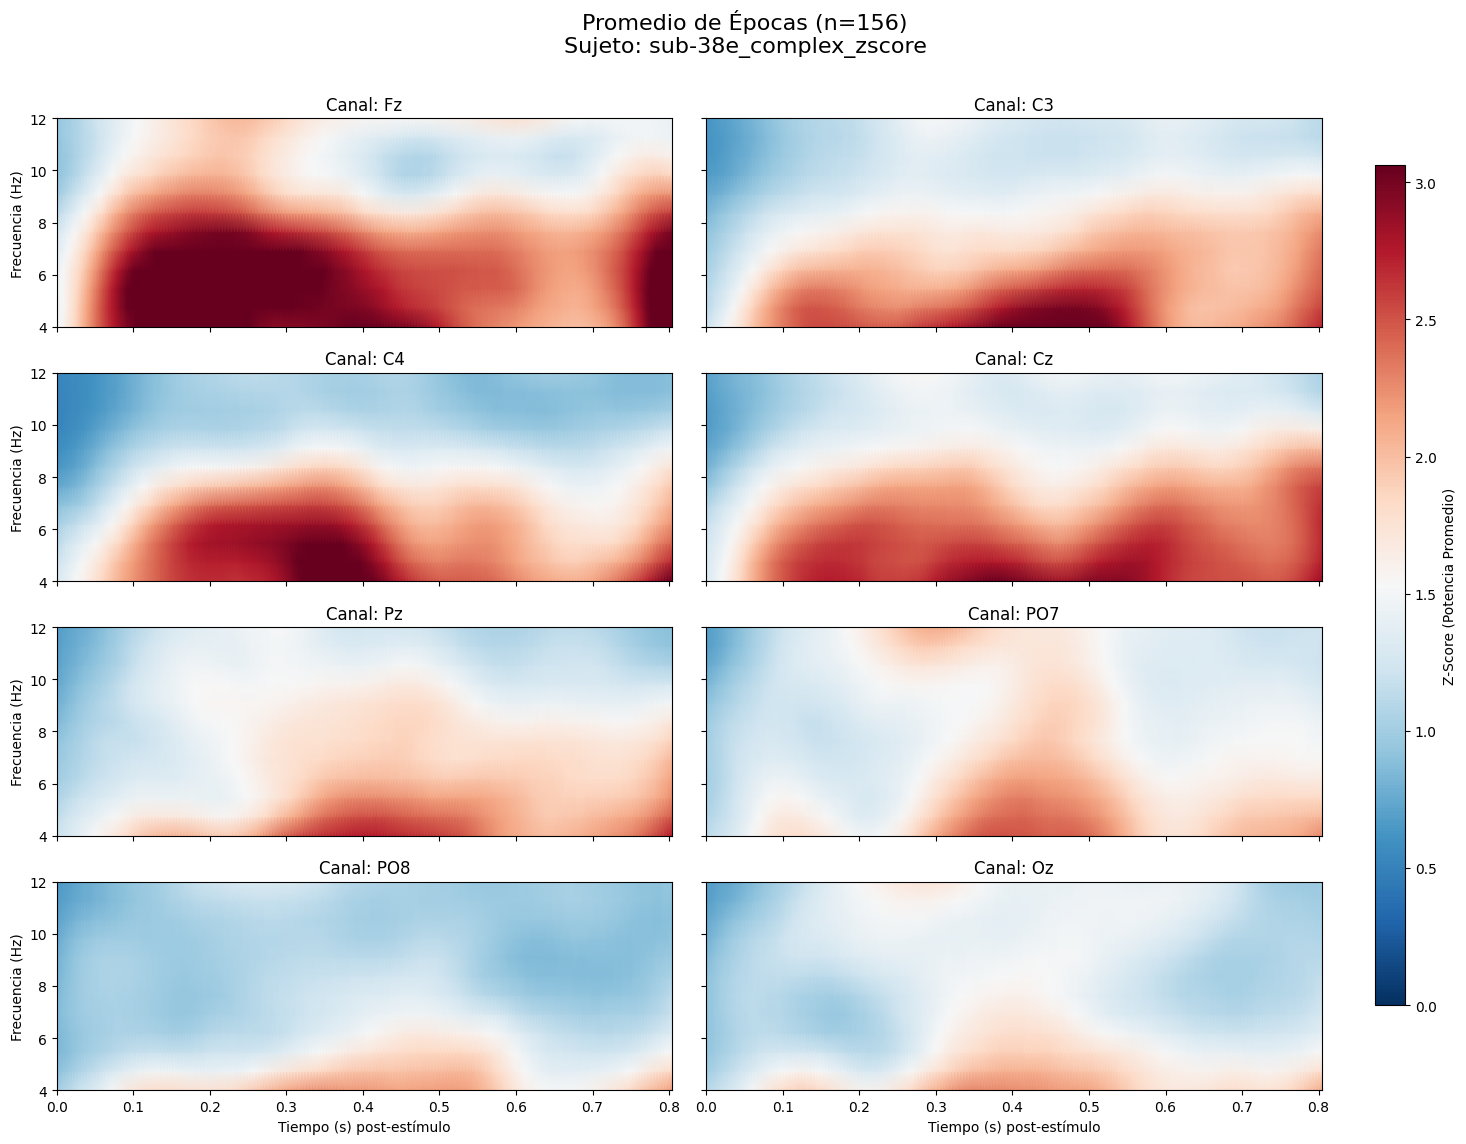

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def plot_tfr_average(file_path, sfreq=250, freqs=None):
    # 1. Cargar datos
    data = np.load(file_path, allow_pickle=True)
    
    # 2. Igualar duraciones
    min_times = min([epoch.shape[2] for epoch in data])
    n_epochs = len(data)
    
    # Extraemos la potencia de cada época y truncamos
    all_power = np.array([np.abs(epoch[:, :, :min_times])**2 for epoch in data]) #(n_epochs, n_channels, n_freqs, min_times)
    
    # 3. Calcular el PROMEDIO de la potencia entre todas las épocas
    avg_power = np.mean(all_power, axis=0) #n_channels, n_freqs, min_times)
    
    # 4. Configuración de canales y tiempo
    target_channels = ['Fz', 'C3', 'C4', 'Cz', 'Pz', 'PO7', 'PO8', 'Oz']
    n_channels, n_freqs, n_times = avg_power.shape
    times = np.arange(n_times) / sfreq 

    # 5. Preparar la figura
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 12), sharex=True, sharey=True)
    axes = axes.flatten()
    
    # Definir límites de color basados en el promedio
    vmax = np.percentile(avg_power, 98)
    vmin = -vmax if np.min(avg_power) < 0 else 0 

    for i, ch_name in enumerate(target_channels):
        ax = axes[i]
        
        # Graficar TFR del promedio
        im = ax.pcolormesh(times, freqs, avg_power[i], 
                           shading='gouraud', 
                           cmap='RdBu_r', 
                           vmin=vmin, vmax=vmax)
        
        ax.set_title(f'Canal: {ch_name}')
        if i % 2 == 0: ax.set_ylabel('Frecuencia (Hz)')
        if i >= 6: ax.set_xlabel('Tiempo (s) post-estímulo')

    # Ajustar diseño y barra de color
    fig.tight_layout(rect=[0, 0.03, 0.9, 0.92])
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Z-Score (Potencia Promedio)')
    
    plt.suptitle(f'Promedio de Épocas (n={n_epochs})\nSujeto: {file_path.stem}', fontsize=16)
    plt.show()

freqs_originales = np.linspace(4, 12, num=12)
plot_tfr_average(CWT_DIR / "sub-38e_complex_zscore.npy", sfreq=250, freqs=freqs_originales)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_group_control_average(sub_list, cwt_dir, sfreq=250, freqs=None):
    # 1. Filtrar sujetos del grupo
    control_subs = sub_list[sub_list['Group'] == 'con']['participant_id'].values
    group_powers = []
    
    print(f"Calculando Grand Average para {len(control_subs)} sujetos del grupo Control...")

    # 2. Cargar y promediar cada sujeto individualmente
    for sub_id in control_subs:
        file_path = cwt_dir / f"{sub_id}_complex_zscore.npy"
        
        if not file_path.exists():
            print(f"Advertencia: No se encontró el archivo para {sub_id}")
            continue
            
        # Cargar épocas del sujeto
        data = np.load(file_path, allow_pickle=True)
        
        # Calcular potencia de cada época y promediar el sujeto
        # Truncamos internamente para este sujeto
        min_t_sub = min([e.shape[2] for e in data])
        sub_power = np.mean([np.abs(e[:, :, :min_t_sub])**2 for e in data], axis=0)
        
        group_powers.append(sub_power)

    if not group_powers:
        print("No se encontraron datos para procesar.")
        return

    # 3. Igualar duraciones entre todos los sujetos del grupo
    # Truncar al tiempo del sujeto que respondió más rápido
    min_t_group = min([p.shape[2] for p in group_powers])
    group_data_truncated = np.array([p[:, :, :min_t_group] for p in group_powers])

    # 4. Grand Average (Promedio de todos los sujetos)
    grand_avg_power = np.mean(group_data_truncated, axis=0)

    # 5. Configuración de visualización
    target_channels = ['Fz', 'C3', 'C4', 'Cz', 'Pz', 'PO7', 'PO8', 'Oz']
    times = np.arange(min_t_group) / sfreq
    
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 12), sharex=True, sharey=True)
    axes = axes.flatten()
    
    vmax = np.percentile(grand_avg_power, 98)
    vmin = -vmax if np.min(grand_avg_power) < 0 else 0

    for i, ch_name in enumerate(target_channels):
        ax = axes[i]
        im = ax.pcolormesh(times, freqs, grand_avg_power[i], 
                           shading='gouraud', cmap='RdBu_r', 
                           vmin=vmin, vmax=vmax)
        
        ax.set_title(f'Canal: {ch_name}')
        if i % 2 == 0: ax.set_ylabel('Frecuencia (Hz)')
        if i >= 6: ax.set_xlabel('Tiempo (s)')

    fig.tight_layout(rect=[0, 0.03, 0.9, 0.92])
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Z-Score Promedio Grupal')
    
    plt.suptitle(f'Grand Average: Grupo Control (n={len(group_powers)})', fontsize=18)
    plt.show()

freqs_originales = np.linspace(4, 12, num=12)
plot_group_control_average(sub_list, CWT_DIR, sfreq=250, freqs=freqs_originales)

Calculando Grand Average para 23 sujetos del grupo Control...


KeyboardInterrupt: 